In [1]:
import numpy as np
from matplotlib import pyplot as plt
import cyipopt
from analysis import *

np.set_printoptions(precision=3, suppress=True)



In [2]:
mag_raw, acc = load_data("data/magacc_readings_14.txt", atol=0.3)
T = -0.907

cal = StreamingExactCalibration(target_dot=T, alpha=1.0, beta=1.0)
for m_raw, a in zip(mag_raw, acc):
    cal.update(m_raw, a)
W_hat, Q_hat, info = cal.solve()
# W_hat[1] *= -1
M_aug = np.column_stack([mag_raw, np.ones(len(mag_raw))])
M = M_aug @ W_hat.T
Mn = M / np.linalg.norm(M, axis=1, keepdims=True)
A = acc / np.linalg.norm(acc, axis=1, keepdims=True)
print(f"{grade(M,M)[0].item():.03f}  {grade(A,M)[0].item():.03f}  {grade(A,Mn)[0].item():.03f}")

for i in range(3):
    cal = StreamingExactCalibration(target_dot=T, alpha=4.0, beta=1.0)
    for m_raw, a in zip(mag_raw, acc):
        cal.update(m_raw, a, W0=W_hat)
    W_hat, Q_hat, info = cal.solve(W0=W_hat)
    M_aug = np.column_stack([mag_raw, np.ones(len(mag_raw))])
    M = M_aug @ W_hat.T
    Mn = M / np.linalg.norm(M, axis=1, keepdims=True)
    A = acc / np.linalg.norm(acc, axis=1, keepdims=True)
    print(f"{grade(M,M)[0].item():.03f}  {grade(A,M)[0].item():.03f}  {grade(A,Mn)[0].item():.03f}")
    
A_hat = W_hat[:, :3]
b_hat = W_hat[:, 3]


0.993  -0.918  -0.922
0.994  -0.902  -0.905
0.997  -0.901  -0.902
0.998  -0.902  -0.903


<Figure size 640x480 with 0 Axes>

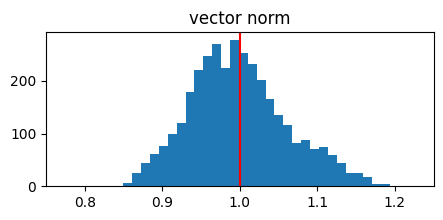

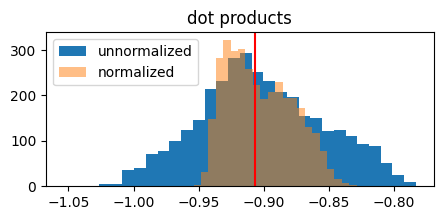

In [3]:
%matplotlib inline

M = (A_hat @ mag_raw.T).T + b_hat
Mn = M / np.linalg.norm(M, axis=1, keepdims=True)
A = acc / np.linalg.norm(acc, axis=1, keepdims=True)

norms = np.array([m@m for m in M])
dots = np.array([m@a for m,a in zip(M,A)])
normdots = np.array([m@a for m,a in zip(Mn,A)])

plt.clf()
plt.figure(figsize=(5,2))
plt.hist(norms, 30)
plt.title("vector norm")
plt.xlim(.75,1.25)
plt.gca().axvline(x=1, c='r')
plt.show()

plt.figure(figsize=(5,2))
plt.hist(dots, 30, label="unnormalized")
plt.hist(normdots, 30, alpha=0.5, color="C1", label="normalized")
plt.title("dot products")
plt.gca().axvline(x=T, c='r')
plt.legend(loc=0)
plt.show()

In [4]:
W_hat

array([[ 0.022, -0.001, -0.001, -0.242],
       [ 0.001,  0.022,  0.   ,  0.267],
       [ 0.001, -0.002,  0.018, -0.557]])

TypeError: ellipsoid_plot() got multiple values for argument 'center'

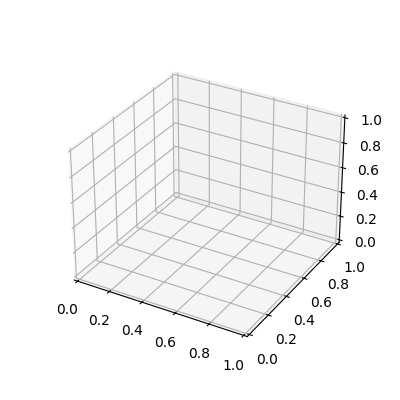

In [6]:
%matplotlib widget
plt.clf()
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')

M = (A_hat @ mag_raw.T).T + b_hat
A = acc / np.linalg.norm(acc, axis=1, keepdims=True)
ellipsoid_plot(ax, center=np.zeros(3), R=np.eye(3), radii=np.ones(3))

ax.scatter(*M.T, c='red', marker='o', s=2, alpha=0.5, label='Mag')
ax.scatter(*A.T, c='blue', marker='o', s=2, alpha=0.5, label='Accel')

plt.show()

In [ ]:
serialize(A_hat, b_hat)